# Importing Your Data with Pandas

Pandas is a very powerful Python tool for reading, writing, and processing tabular data. Most Python plotting functionality is set up to work with pandas-formatted datasets. Tabular data is stored as a Python object called a `DataFrame` in pandas (often shortened to `df` in documentation). We'll start by importing the pandas package and reading the example data included in the day-3 directory.

You are invited to provide your feedback to today's workshop session with this [survey](https://forms.office.com/r/7EtNFtUDm0?origin=lprLink) to be completed at any time.

In [ ]:
import pandas as pd

We'll be importing data from a CSV file in this tutorial, but pandas has wide support for tabular data formats such as Excel, SQL, txt, and Parquet.

In [14]:
example_data_file = 'pub_trend_example_data.csv'

data = pd.read_csv(example_data_file)
data.head()

,Year,Viral Vectors,Lipid Nanoparticles,Metal Nanoparticles,Carbon Nanomaterials,Hydrogels,Synthetic Polymer Nanostructures,Peptide Nanostructures,Polysaccharide Nanostructures
0,1990,21,25,0,0,2,1,0,0
1,1991,41,50,0,0,9,4,0,1
2,1992,72,56,0,0,15,4,1,0
3,1993,128,82,0,0,14,8,1,0
4,1994,247,135,0,0,17,18,3,1


Here's how we easily get the rows and columns:

In [15]:
columns = data.columns
index = data.index

print(columns)
print(index)

Index(['Year', 'Viral Vectors', 'Lipid Nanoparticles', 'Metal Nanoparticles',
       'Carbon Nanomaterials', 'Hydrogels', 'Synthetic Polymer Nanostructures',
       'Peptide Nanostructures', 'Polysaccharide Nanostructures'],
      dtype='object')
RangeIndex(start=0, stop=36, step=1)


By default when loading a dataset the index is just a range of integers from 0 to the total number of rows in your spreadsheet, but we can change this later.

In [16]:
data['Hydrogels'].tail(5)

31    1586
32    1836
33    1972
34    2195
35     423
Name: Hydrogels, dtype: int64

We can select a subset of our original dataset including only specified columns with `[[]]`

In [17]:
data[['Year', 'Hydrogels', 'Synthetic Polymer Nanostructures']].head()

,Year,Hydrogels,Synthetic Polymer Nanostructures
0,1990,2,1
1,1991,9,4
2,1992,15,4
3,1993,14,8
4,1994,17,18


We can also select a row slice by calling its index numerically. Numerical indexing in Python can be a little tricky for beginners; in general, tabular data is indexed using the formula: `[[row_start:row_end],[col_start:col_end]]` where the `_end` values are not inclusive. A more detailed look at Python indexing can be found [here](https://www.freecodecamp.org/news/slicing-and-indexing-in-python/).

In [18]:
data[0:3]

,Year,Viral Vectors,Lipid Nanoparticles,Metal Nanoparticles,Carbon Nanomaterials,Hydrogels,Synthetic Polymer Nanostructures,Peptide Nanostructures,Polysaccharide Nanostructures
0,1990,21,25,0,0,2,1,0,0
1,1991,41,50,0,0,9,4,0,1
2,1992,72,56,0,0,15,4,1,0


Sometimes we intend for a column of our `DataFrame` to serve as the index instead of the one `pandas` generates by default. We can specify which column should instead be the index upon reading in our data file:

In [19]:
data = pd.read_csv('pub_trend_example_data.csv', index_col='Year')
data.head()

,Viral Vectors,Lipid Nanoparticles,Metal Nanoparticles,Carbon Nanomaterials,Hydrogels,Synthetic Polymer Nanostructures,Peptide Nanostructures,Polysaccharide Nanostructures
Year,,,,,,,,
1990,21,25,0,0,2,1,0,0
1991,41,50,0,0,9,4,0,1
1992,72,56,0,0,15,4,1,0
1993,128,82,0,0,14,8,1,0
1994,247,135,0,0,17,18,3,1


In [20]:
print(data.index)
print(data.columns)

Index([1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001,
       2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013,
       2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025],
      dtype='int64', name='Year')
Index(['Viral Vectors', 'Lipid Nanoparticles', 'Metal Nanoparticles',
       'Carbon Nanomaterials', 'Hydrogels', 'Synthetic Polymer Nanostructures',
       'Peptide Nanostructures', 'Polysaccharide Nanostructures'],
      dtype='object')


For more precise selection and slicing, we can use the `DataFrame.loc` and `DataFrame.iloc` methods to select parts of our `DataFrame` by label or numerical index, respectively:

In [21]:
# To select a row:
data.loc[2007] # '2007' is technically the label of the index, not the index value itself
data.iloc[17]

# To select all rows of a single column:
data.loc[:, 'Peptide Nanostructures'] # Equivalent to data['Peptide Nanostructures']
data.iloc[:, 6]

# To select the element of a row/col coordinate:
data.loc[2007, 'Peptide Nanostructures'] # data.at[] performs the same function but much faster
data.iloc[17, 6]                         # data.iat[] performs the same function but much faster

# To select specific rows of a single column:
data.loc[2000:2003, 'Peptide Nanostructures']
data.iloc[10:14, 6]

# To select a specific row/col subset of the original DataFrame:
data.loc[2000:2003, ['Peptide Nanostructures', 'Polysaccharide Nanostructures']]
data.iloc[10:14, [6, 7]] # This is equivalent to data.iloc[10:14, [6:8]]

,Peptide Nanostructures,Polysaccharide Nanostructures
Year,,
2000,10,13
2001,14,12
2002,21,17
2003,23,24


A few more advanced examples of `DataFrame` operations in pandas are listed below. More information on stats, merge, join, group, category, and other methods are detailed [here](https://pandas.pydata.org/docs/user_guide/10min.html).

In [29]:
# Get the transpose of your data:
data.T

# Sort by axis:
data.sort_index(axis=1, ascending=False)

# Sort by the values of a column:
data.sort_values(by='Viral Vectors')

# Get all rows where "Polysaccharide Nanostructures" is greater than 0:
data[data['Polysaccharide Nanostructures'] > 0]

# Filter the dataset by a specified mask:
mask = range(1000, 1500)
data[data['Polysaccharide Nanostructures'].isin(mask)]

,Viral Vectors,Lipid Nanoparticles,Metal Nanoparticles,Carbon Nanomaterials,Hydrogels,Synthetic Polymer Nanostructures,Peptide Nanostructures,Polysaccharide Nanostructures
Year,,,,,,,,
2016,1207,1793,399,1135,946,1849,776,1075
2017,1257,1953,516,1250,1081,2027,911,1163
2018,1286,2094,645,1483,1206,2190,1005,1230
2019,1315,2044,635,1313,1289,1923,933,1238
2020,1513,2380,715,1414,1418,2081,982,1398
2021,1793,2532,899,1521,1586,1967,1012,1478
2022,1648,2643,922,1439,1836,1890,1027,1477
2023,1731,2565,898,1468,1972,1793,883,1445


Some statistical functions are built into pandas and can be easily applied to an imported `DataFrame`. the `.describe()` method gives a stats overview of each column of a `DataFrame`:

In [ ]:
data.describe()

,Viral Vectors,Lipid Nanoparticles,Metal Nanoparticles,Carbon Nanomaterials,Hydrogels,Synthetic Polymer Nanostructures,Peptide Nanostructures,Polysaccharide Nanostructures
count,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000
mean,955.888889,950.805556,228.777778,460.777778,538.333333,746.361111,339.750000,459.805556
std,490.405475,891.832490,319.555058,579.638760,633.403234,817.109160,391.614269,561.386336
min,21.000000,25.000000,0.000000,0.000000,2.000000,1.000000,0.000000,0.000000
25%,603.000000,269.750000,0.000000,1.750000,50.750000,24.250000,9.000000,7.500000
50%,1035.500000,542.500000,41.000000,128.000000,257.000000,330.000000,143.500000,148.500000
75%,1212.000000,1571.750000,335.250000,921.250000,812.500000,1639.750000,689.000000,889.000000
max,1821.000000,2859.000000,951.000000,1521.000000,2195.000000,2190.000000,1027.000000,1543.000000


Pandas also has built-in matplotlib functionality which can be used to quickly visualize your data:

<Axes: xlabel='Year'>

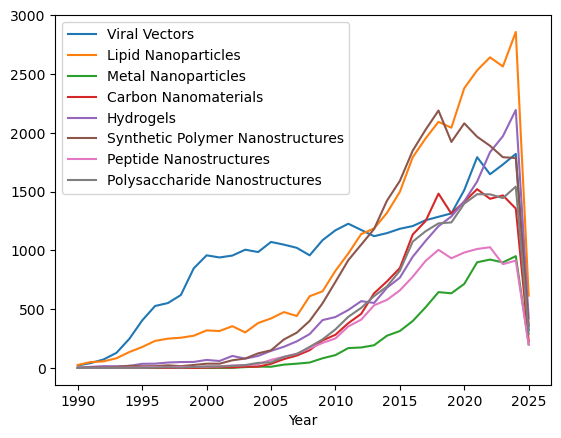

In [ ]:
data.plot()

Resources:

- [10-Minute Guide to Pandas](https://pandas.pydata.org/docs/user_guide/10min.html)
- [Slicing and Indexing in Python](https://www.freecodecamp.org/news/slicing-and-indexing-in-python/)

[Feedback Survey](https://forms.office.com/r/7EtNFtUDm0?origin=lprLink)